<a href="https://colab.research.google.com/github/merlyn257/Housing_CodeAnalysis/blob/main/OAG_Code_for_Housing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
print("Preparing OAG Housing Analysis...")

Preparing OAG Housing Analysis...


In [57]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [58]:
# The URL for the Housing Violations dataset (NYC OPEN DATA)
url = "https://data.cityofnewyork.us/resource/wvxf-dwi5.csv?$limit=5000"

# Loading into a Pandas DataFrame for storing
df = pd.read_csv(url)

# Looking at first 5 rows
df.head()

,violationid,buildingid,registrationid,boroid,boro,housenumber,lowhousenumber,highhousenumber,streetname,streetcode,...,violationstatus,rentimpairing,latitude,longitude,communityboard,councildistrict,censustract,bin,bbl,nta
0,10081311,375411,306067,3,BROOKLYN,22 FRONT,22 FRON,22 FRONT,STAGG STREET,80930,...,Close,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10299683,375411,306067,3,BROOKLYN,22 FRONT,22 FRON,22 FRONT,STAGG STREET,80930,...,Close,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10299685,375411,306067,3,BROOKLYN,22 FRONT,22 FRON,22 FRONT,STAGG STREET,80930,...,Close,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10299686,375411,306067,3,BROOKLYN,22 FRONT,22 FRON,22 FRONT,STAGG STREET,80930,...,Open,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10299690,375411,306067,3,BROOKLYN,22 FRONT,22 FRON,22 FRONT,STAGG STREET,80930,...,Open,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
# 1. Make all column names lowercase and remove hidden spaces
df.columns = df.columns.str.lower().str.strip()

# 2. Print out the columns as a list to see names
print("Column names:")
print(df.columns.tolist())

Column names:
['violationid', 'buildingid', 'registrationid', 'boroid', 'boro', 'housenumber', 'lowhousenumber', 'highhousenumber', 'streetname', 'streetcode', 'zip', 'apartment', 'story', 'block', 'lot', 'class', 'inspectiondate', 'approveddate', 'originalcertifybydate', 'originalcorrectbydate', 'newcertifybydate', 'newcorrectbydate', 'certifieddate', 'ordernumber', 'novid', 'novdescription', 'novissueddate', 'currentstatusid', 'currentstatus', 'currentstatusdate', 'novtype', 'violationstatus', 'rentimpairing', 'latitude', 'longitude', 'communityboard', 'councildistrict', 'censustract', 'bin', 'bbl', 'nta']


In [60]:
# 1. Convert the inspection date to a proper date format
df['inspectiondate'] = pd.to_datetime(df['inspectiondate'])

# 2. Filter for only 'Class C' (Immediately Hazardous) violations
severe_violations = df[df['class'] == 'C'].copy()

# 3. Drop rows with missing Zip Codes to clean 'dirty' data
severe_violations = severe_violations.dropna(subset=['zip'])

print(f"Filtered down to {len(severe_violations)} hazardous violations.")

Filtered down to 960 hazardous violations.


Top 10 Zip Codes with Severe Housing Violations:
 zip_code  violation_count
  10031.0               87
  10453.0               87
  10457.0               62
  10458.0               59
  10032.0               54
  11206.0               53
  10467.0               53
  11207.0               34
  10026.0               32
  10456.0               26


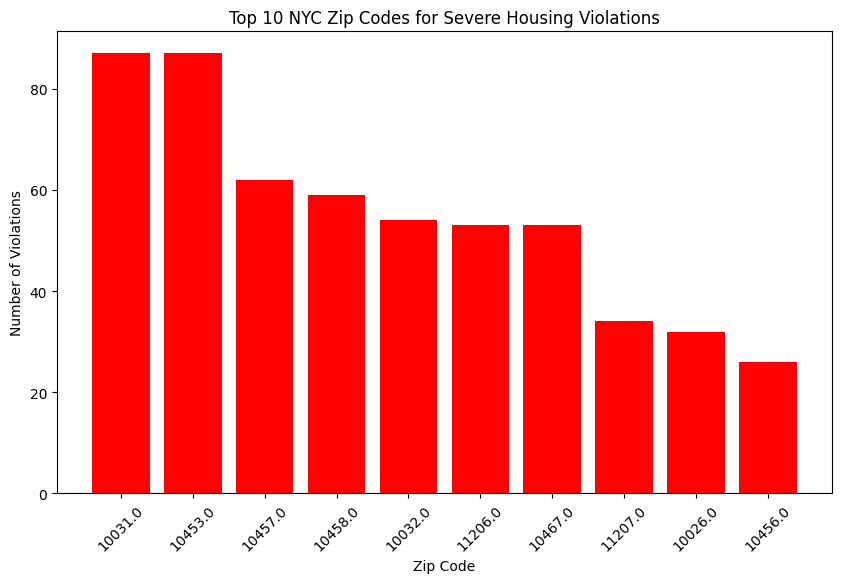

In [61]:
summary = severe_violations['zip'].value_counts().reset_index()

# Rename columns
summary.columns = ['zip_code', 'violation_count']

# Top 10
top_10_hotspots = summary.head(10)

print("Top 10 Zip Codes with Severe Housing Violations:")
# .to_string(index=False) to remove index numbers 0, 1, 2, 3
print(top_10_hotspots.to_string(index=False))

# --- PLOTTING ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# .astype(str) converts to labels string.
plt.bar(top_10_hotspots['zip_code'].astype(str), top_10_hotspots['violation_count'], color='red')

plt.title('Top 10 NYC Zip Codes for Severe Housing Violations')
plt.xlabel('Zip Code')
plt.ylabel('Number of Violations')
plt.xticks(rotation=45)
plt.show()

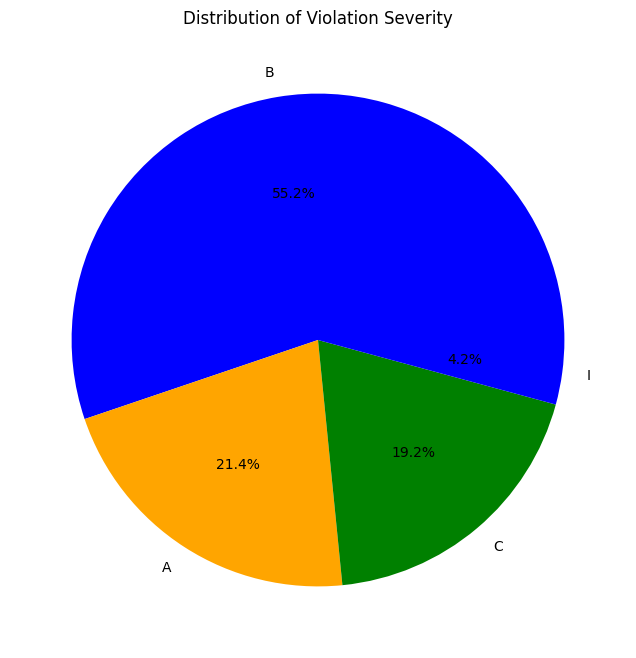

In [62]:
# Expanding analysis further
# Group by 'class' and count
severity_counts = df['class'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%', colors=['blue', 'orange', 'green'])
plt.title('Distribution of Violation Severity')
plt.show()

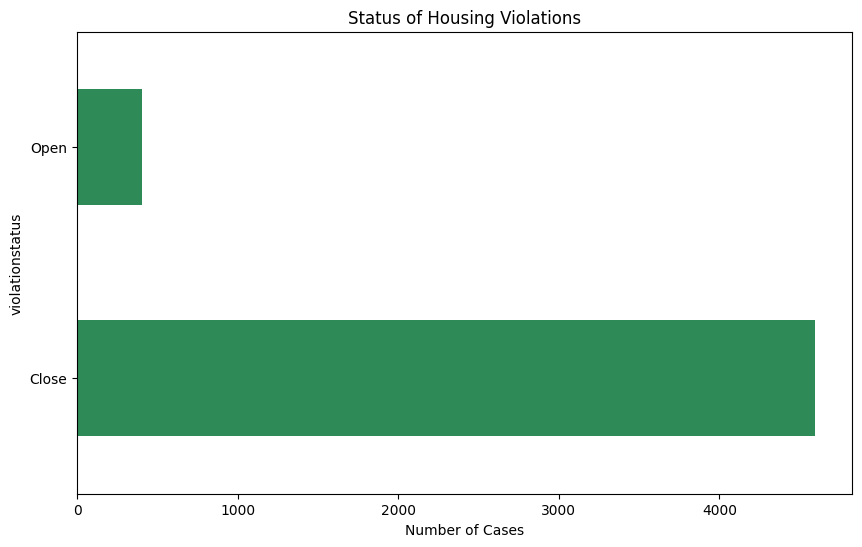

In [63]:
violationstatus = df['violationstatus'].value_counts()

plt.figure(figsize=(10, 6))
violationstatus.plot(kind='barh', color='seagreen')
plt.title('Status of Housing Violations')
plt.xlabel('Number of Cases')
plt.show()

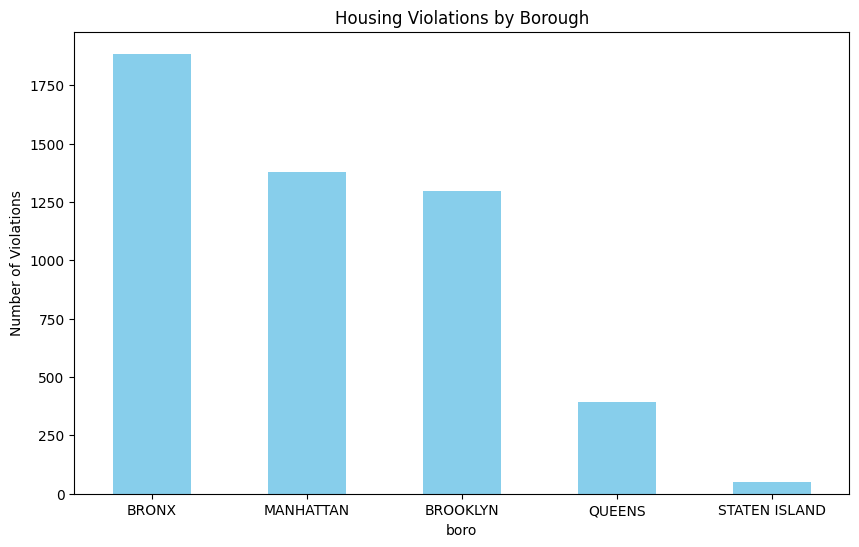

In [64]:
borough = df['boro'].value_counts()

plt.figure(figsize=(10, 6))
borough.plot(kind='bar', color='skyblue')
plt.title('Housing Violations by Borough')
plt.ylabel('Number of Violations')
plt.xticks(rotation=0)
plt.show()

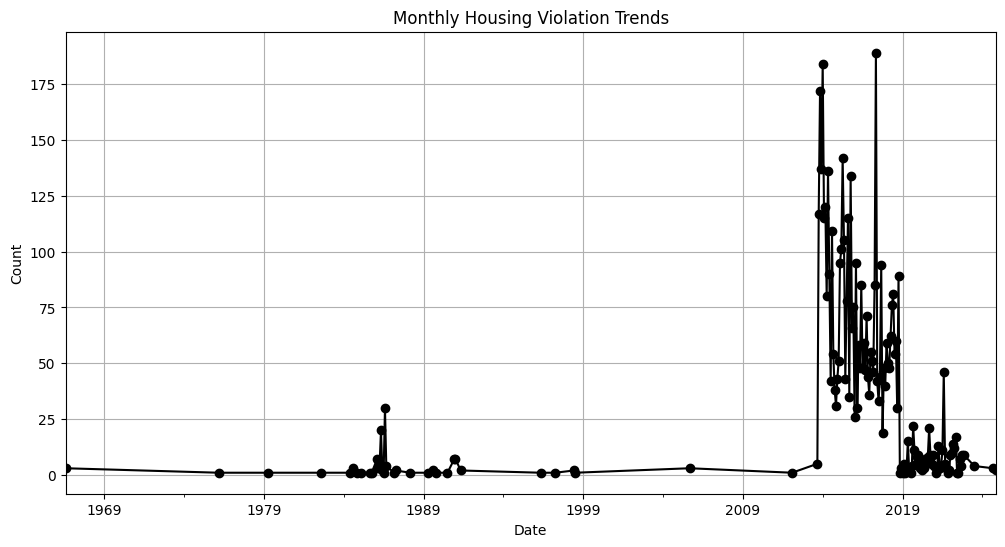

In [65]:
# Group by Month and Year
df['month_year'] = df['inspectiondate'].dt.to_period('M')
timeline = df.groupby('month_year').size()

plt.figure(figsize=(12, 6))
timeline.plot(marker='o', color='black')
plt.title('Monthly Housing Violation Trends')
plt.xlabel('Date')
plt.ylabel('Count')
plt.grid(True)
plt.show()